# Arc-Length Controlled Shape Design

Numerical demonstrations behind

> Bouwer, J. M., Kok, S. and Wilke, D. N. (2023). *Challenges and solutions to
> arc-length controlled structural shape design problems.* Mechanics Based Design of
> Structures and Machines, **51**(7), 4088–4119.
> [doi:10.1080/15397734.2021.1950549](https://doi.org/10.1080/15397734.2021.1950549)

Three things are shown here:

1. **Large arc-length steps pay for themselves** in solution time.
2. **A four-variable design space** — different design radii give different arches.
3. **Those arches solved with Q8 elements**, giving their load-deflection paths.

The optimisation half of the paper — the curve-matching objective functions, the
discontinuities that adaptive arc stepping creates in them, and the gradient-only
optimisers that tolerate those discontinuities — is not covered here.

In [1]:
import contextlib
import logging
import sys
import time

import matplotlib.pyplot as plt
import numpy as np

from fem2d.meshers import Mesh, Q8Mesh
from fem2d.postprocessing import Plotting
from fem2d.solvers import ArcLengthSolver

logging.basicConfig(level=logging.INFO, format='%(message)s', stream=sys.stdout)
SolverLog = logging.getLogger('fem2d.solvers')


@contextlib.contextmanager
def quiet():
    # The solvers log every iteration; silence them for the sweeps.
    SolverLog.setLevel(logging.WARNING)
    try:
        yield
    finally:
        SolverLog.setLevel(logging.NOTSET)

## The structure

A deep circular arch spanning 215°, clamped at one end and pinned at the other. The
asymmetry matters: it makes the arch always deform towards the pinned side, which is the
softer of the two.

The paper publishes the geometry and the design setup — radius 100 mm, design radii
between 80 and 120 mm, the end radii held at 100 mm, and a cubic spline through them —
but not the material constants. The section here is therefore taken from the
DaDeppo and Schmidt benchmark the arch comes from, which is stated as
$EA = EI = 10^6$. For a rectangular section of unit out-of-plane thickness that fixes
both the depth and the modulus:

$$\frac{I}{A} = \frac{h^2}{12} = 1 \;\Rightarrow\; h = \sqrt{12},
\qquad EA = Eh = 10^6 \;\Rightarrow\; E = \frac{10^6}{\sqrt{12}}$$

In [2]:
h = np.sqrt(12.0)              # radial depth of the arch
E = 1e6/h                      # so that EA = EI = 1e6
v, t, plane = 0.3, 1.0, 0      # plane stress: a beam of unit width
R = 100.0                      # base radius, held at the two ends
Load = -1.0                    # unit point load at the crown, scaled by the load factor

print(f'depth h = {h:.4f}   E = {E:,.1f}')
print(f'EA = {E*t*h:,.4g}   EI = {E*t*h**3/12:,.4g}')


def Arch(ElementType, el_num, radii):
    m = (Q8Mesh if ElementType == 'Q8' else Mesh)(E, v, t, plane, ElementType)
    m.SemiCircularArch(el_num, R, list(radii), h, Load)
    return m

depth h = 3.4641   E = 288,675.1
EA = 1e+06   EI = 1e+06


12 elements, 63 nodes, 4 design variables


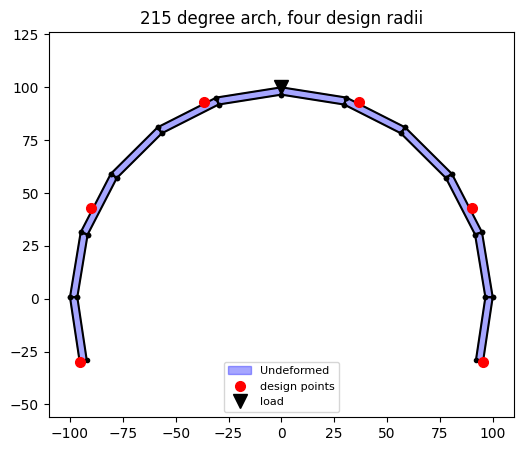

In [3]:
m = Arch('Q8', 12, [R]*4)

ax = Plotting.InitialMesh(m, alpha=0.35)
ax.plot(m.VarPos[0], m.VarPos[1], 'ro', ms=7, label='design points')
ax.plot(m.Nodes[m.LoadNode//2, 1], m.Nodes[m.LoadNode//2, 2], 'kv', ms=10, label='load')
ax.set_title('215 degree arch, four design radii')
ax.legend(loc='lower center', fontsize=8)
ax.figure.set_size_inches(6, 5)

print(f'{m.Elements.shape[0]} elements, {m.Nodes.shape[0]} nodes, '
      f'{m.VariableNumber} design variables')

## 1. Why large arc-length steps pay

The arc-length method walks along the equilibrium path in fixed increments of arc length
rather than of load, which is what lets it round a limit point. The prescribed step is a
free choice, and when a step will not converge the solver halves it by $\sqrt{2}$ and
retries.

Small steps look safe but cost time. Large steps cover ground quickly but start to
trigger those retries. Sweeping the prescribed arc length on one fixed design shows both
ends of that trade.

In [4]:
class CountCuts(logging.Handler):
    # The solver logs a line whenever it reduces the arc step.
    def __init__(self):
        super().__init__()
        self.cuts = 0

    def emit(self, record):
        if 'cutting' in record.getMessage():
            self.cuts += 1


Total = 800.0
Sweep = [160.0, 80.0, 40.0, 20.0, 10.0]
Rows = []

for ArcLength in Sweep:
    Counter = CountCuts()
    SolverLog.handlers = [Counter]
    SolverLog.setLevel(logging.INFO)
    # The counter needs the records, but they must not also reach the root
    # handler, or every iteration lands in the notebook output.
    SolverLog.propagate = False

    m = Arch('5B', 20, [R]*4)
    Start = time.perf_counter()
    ArcLengthSolver(m, ArcLength=ArcLength, TotalArcLength=Total, tol=1e-6, MaxIter=9).Solve()
    Elapsed = time.perf_counter() - Start

    Lam = np.ravel(m.LoadValues)
    Rows.append((ArcLength, len(Lam) - 1, Counter.cuts, Elapsed, Lam.max()))

SolverLog.handlers = []
SolverLog.propagate = True

print(f"{'arc length':>11}{'steps':>7}{'cuts':>6}{'time (s)':>10}{'lambda max':>12}")
for ArcLength, Steps, Cuts, Elapsed, LamMax in Rows:
    print(f'{ArcLength:>11.1f}{Steps:>7}{Cuts:>6}{Elapsed:>10.2f}{LamMax:>12.1f}')

 arc length  steps  cuts  time (s)  lambda max
      160.0     12    39     48.10      1246.0
       80.0     15    23     28.73      1242.1
       40.0     23     9     23.43      1241.7
       20.0     41     2     33.03      1247.1
       10.0     80     0     54.29      1247.4


`lambda max` barely moves across the sweep, so every run traced the same path and the
times are comparable.

The paper's Table 1 reports the same trend on its own arch, monotonically: step lengths
of 100, 50, 25, 12.5 and 6.25 took 26.2, 42.5, 53.7, 89.6 and 163.8 seconds. Halving the
step roughly doubles the cost.

What the sweep here adds is the other end of the curve. Past a point, a larger step stops
paying: the solver spends its time cutting back and retrying, so the cost turns round
again. The cheapest setting is the largest step that is *not* provoking many retries.

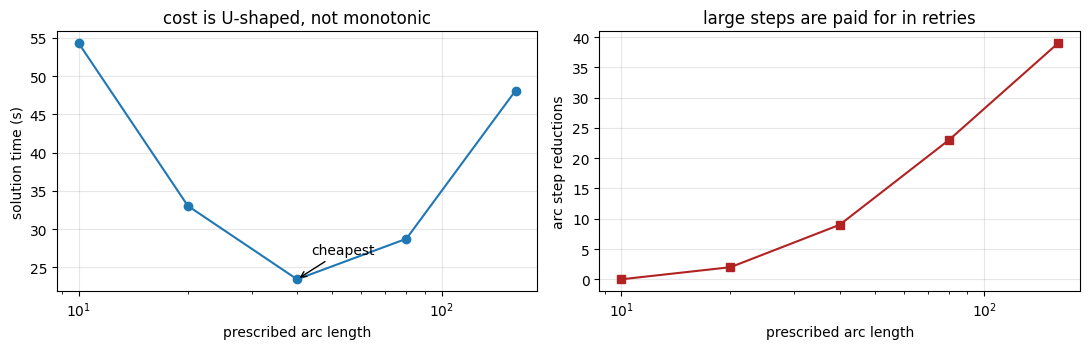

In [5]:
ArcLengths = [r[0] for r in Rows]
Times = [r[3] for r in Rows]
Cuts = [r[2] for r in Rows]

fig, (a1, a2) = plt.subplots(1, 2, figsize=(11, 3.6))

a1.plot(ArcLengths, Times, 'o-')
a1.set(xscale='log', xlabel='prescribed arc length', ylabel='solution time (s)',
       title='cost is U-shaped, not monotonic')
a1.grid(alpha=0.3)
Best = int(np.argmin(Times))
a1.annotate('cheapest', xy=(ArcLengths[Best], Times[Best]),
            xytext=(10, 18), textcoords='offset points',
            arrowprops=dict(arrowstyle='->'))

a2.plot(ArcLengths, Cuts, 's-', color='firebrick')
a2.set(xscale='log', xlabel='prescribed arc length', ylabel='arc step reductions',
       title='large steps are paid for in retries')
a2.grid(alpha=0.3)
plt.tight_layout()

## 2. The four-variable design space

The shape parameters are the arch radius at four equally spaced angles. The two ends stay
at 100 mm and a cubic spline runs the radius through all six points, so a design is four
numbers and the arch follows.

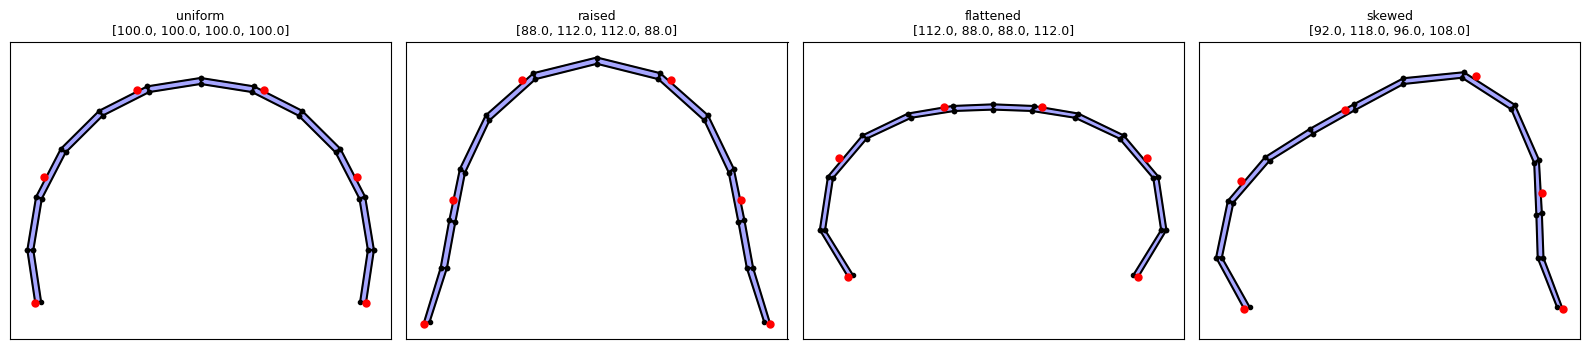

In [6]:
Designs = {
    'uniform':   [R, R, R, R],
    'raised':    [88.0, 112.0, 112.0, 88.0],
    'flattened': [112.0, 88.0, 88.0, 112.0],
    'skewed':    [92.0, 118.0, 96.0, 108.0],
}

fig, axes = plt.subplots(1, 4, figsize=(16, 3.6))
for ax, (Name, radii) in zip(axes, Designs.items(), strict=True):
    m = Arch('Q8', 12, radii)
    Plotting.InitialMesh(m, ax=ax, alpha=0.35)
    ax.plot(m.VarPos[0], m.VarPos[1], 'ro', ms=5)
    ax.set_title(f'{Name}\n{radii}', fontsize=9)
    ax.set_xticks([])
    ax.set_yticks([])
plt.tight_layout()

## 3. Load paths, solved with Q8

Each design is now traced with the arc-length solver using eight-node elements. The load
factor is plotted against the crown displacement, so the peak of each curve is the limit
point at which that arch snaps through.

Watch the flattened design in particular. Its path turns back on itself in
*displacement* as well as in load, which is snap-back. Neither load control nor
displacement control can trace a curve like that; only arc-length control can, which is
the whole reason the design study needs it.

In [7]:
Paths = {}
for Name, radii in Designs.items():
    m = Arch('Q8', 12, radii)
    Start = time.perf_counter()
    with quiet():
        ArcLengthSolver(m, ArcLength=50.0, TotalArcLength=900.0, tol=1e-6, MaxIter=9).Solve()
    Paths[Name] = m
    Lam = np.ravel(m.LoadValues)
    print(f'{Name:<11} {len(Lam)-1:2d} steps, {time.perf_counter()-Start:5.1f} s, '
          f'limit load {Lam.max():8.1f}')

uniform     20 steps,  44.7 s, limit load   2345.4


raised      19 steps,  39.8 s, limit load   2267.7


flattened   19 steps,  48.0 s, limit load   1754.7


skewed      18 steps,  37.9 s, limit load   1792.4


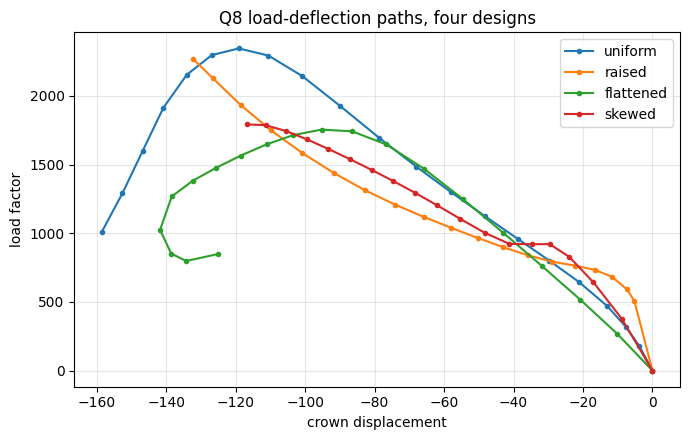

In [8]:
fig, ax = plt.subplots(figsize=(7, 4.5))
for Name, m in Paths.items():
    ax.plot(m.AllU[m.LoadNode, :], np.ravel(m.LoadValues), 'o-', ms=3, label=Name)
ax.set(xlabel='crown displacement', ylabel='load factor',
       title='Q8 load-deflection paths, four designs')
ax.grid(alpha=0.3)
ax.legend()
plt.tight_layout()

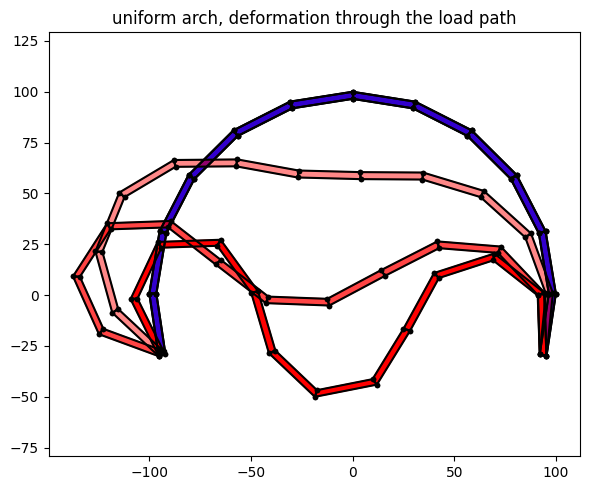

In [9]:
# The deformed shape of one design through its snap-through.
m = Paths['uniform']
fig, ax = plt.subplots(figsize=(6, 5))
Plotting.Overlay(m, ax=ax, steps=6)
ax.set_title('uniform arch, deformation through the load path')
plt.tight_layout()

## What this sets up, and one caveat

The paths above are what the shape design problem is built on. Given a *target* path, the
inverse problem is to find the design radii that reproduce it, and that needs an objective
function comparing two curves. Because the arc-length solver returns its solutions at
whatever accumulated arc lengths its adaptive stepping happens to land on, and because
that stepping changes discontinuously with the design, the objective function is
discontinuous — which is the subject of the paper and is not covered here.

**Caveat on the limit load.** The peak load factor is *not* mesh converged for this
problem as set up. Refining along the arch with everything else fixed gives, for the
uniform design with 5β elements, limit loads of 1247, 783, 672 and 616 for 20, 40, 60 and
80 elements, with the crown deflection at the limit falling alongside it. It is not a
point-load singularity — sharing the load across the crown cross-section moves the answer
by under 0.1% — and it is not the solver, since refining the arc length on a *fixed* mesh
converges cleanly. The likely cause is that the arc-length constraint sums over every free
degree of freedom, so a fixed total arc length covers less of the physical path as the
mesh is refined. That is an open question.

Nothing above depends on it: the arc-length sweep holds the mesh fixed and varies only the
step, and the design comparison holds the mesh fixed and varies only the shape. But the
limit loads should be read as relative to one another, not as converged values.